# Diversity vs. Correctness

Comparing **Qwen3-Coder-30B-A3B** and **Qwen3-Coder-Next** (KernelBench Level-1, Triton):

1. **Do problems with higher sample diversity have more correct samples?** — correlation between per-problem kernel diversity (mean pairwise AST distance) and the number of correct samples.
2. **Diversity across `all-wrong`, `few-correct`, `all-correct`** — three-group boxplot comparison.
3. **Full gradient** — per-exact-correct-count breakdown (0 → 1 → 2 → …) to show whether the jump is a step at 0→1 or a gradual trend.

Reads the already-computed `analysis/stage1_per_problem.csv` (correctness) and `analysis/stage2_ast_struct_summary.csv` (AST diversity) for each run. Run all cells.

## ⚙️ Config

In [64]:
from pathlib import Path

RUNS_ROOT = Path("/home/jan-bosenius/PycharmProjects/GuidedResearch/notebooks/runs")

RUNS = {
    "Qwen3-Coder-30B-A3B": "Qwen3-Coder-30B-A3B-Instruct_level1_triton",
    "Qwen3-Coder-Next":    "Qwen3-Coder-Next_level1_triton",
}

DIVERSITY_COL = "mean_pairwise_dist"

# 'few-correct': 1 <= correct <= FEW_MAX  |  'all-correct': correct > FEW_MAX
FEW_MAX = 3

## Load & merge per-problem correctness + diversity

In [65]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


def load_run(folder: str) -> pd.DataFrame:
    a = RUNS_ROOT / folder / "analysis"
    s1 = pd.read_csv(a / "stage1_per_problem.csv")
    s2 = pd.read_csv(a / "stage2_ast_struct_summary.csv")
    df = s1.merge(s2[["problem_id", DIVERSITY_COL, "parse_fail"]], on="problem_id", how="left")
    df = df.rename(columns={DIVERSITY_COL: "diversity"})
    df["n_parseable"] = df["total"] - df["parse_fail"].fillna(0)
    df.loc[df["n_parseable"] < 2, "diversity"] = np.nan
    return df


data = {label: load_run(folder) for label, folder in RUNS.items()}
for label, df in data.items():
    print(f"{label:22s} problems={len(df):3d}  with diversity={df['diversity'].notna().sum():3d}  "
          f"mean correct/problem={df['correct'].mean():.2f}")
data[next(iter(RUNS))].head()

Qwen3-Coder-30B-A3B    problems=100  with diversity=100  mean correct/problem=1.30
Qwen3-Coder-Next       problems=100  with diversity=100  mean correct/problem=1.61


,problem_id,total,compiled,correct,compiled_wrong,failed,rt_avg_ms,rt_min_ms,rt_max_ms,rt_spread_ms,error_diversity,error_counts,diversity,parse_fail,n_parseable
0,1,10,10,0,10,0,NaN,NaN,NaN,NaN,diverse (2 error types),"{""subprocess.CalledProcessError"": 8, ""builtins...",0.068476,0,10
1,2,10,10,0,10,0,NaN,NaN,NaN,NaN,diverse (2 error types),"{""subprocess.CalledProcessError"": 7, ""builtins...",0.097123,0,10
2,3,10,10,0,10,0,NaN,NaN,NaN,NaN,diverse (3 error types),"{""subprocess.CalledProcessError"": 4, ""triton.c...",0.253385,0,10
3,4,10,10,0,10,0,NaN,NaN,NaN,NaN,diverse (3 error types),"{""builtins.AttributeError"": 2, ""subprocess.Cal...",0.100335,0,10
4,5,10,10,0,10,0,NaN,NaN,NaN,NaN,homogeneous [subprocess.CalledProcessError],"{""subprocess.CalledProcessError"": 10}",0.029800,0,10


## Q1 — Does higher diversity go with more correct samples?

Per problem: `diversity` (mean pairwise AST distance) vs `correct` (count of correct samples out of `total`).
Reports Pearson r and Spearman ρ (rank, robust to non-linearity). Problems with undefined diversity are dropped.

In [66]:
corr_rows = []
for label, df in data.items():
    d = df.dropna(subset=["diversity", "correct"])
    pear_r, pear_p = stats.pearsonr(d["diversity"], d["correct"])
    spear_r, spear_p = stats.spearmanr(d["diversity"], d["correct"])
    corr_rows.append(dict(run=label, n=len(d),
                          pearson_r=round(pear_r, 3), pearson_p=round(pear_p, 4),
                          spearman_rho=round(spear_r, 3), spearman_p=round(spear_p, 4)))
print("Correlation: diversity vs. number of correct samples (per problem)")
pd.DataFrame(corr_rows)

Correlation: diversity vs. number of correct samples (per problem)


,run,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Qwen3-Coder-30B-A3B,100,-0.198,0.0488,0.173,0.0846
1,Qwen3-Coder-Next,100,-0.454,0.0000,-0.167,0.0977


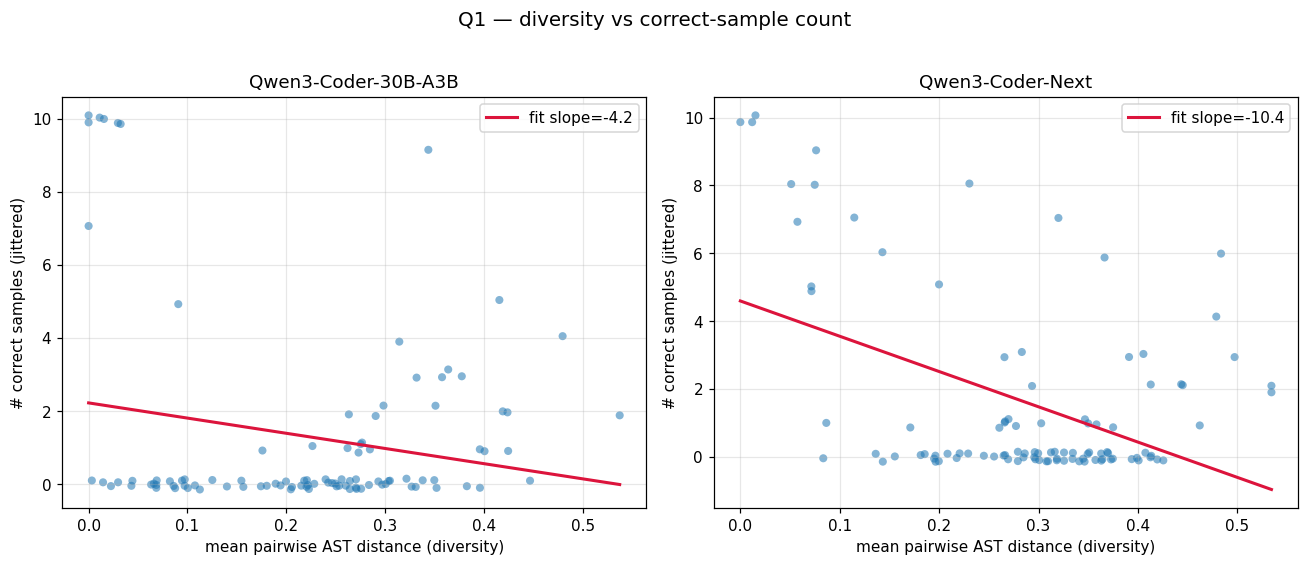

In [67]:
fig, axes = plt.subplots(1, len(data), figsize=(6 * len(data), 5), squeeze=False)
for ax, (label, df) in zip(axes[0], data.items()):
    d = df.dropna(subset=["diversity", "correct"])
    y = d["correct"] + np.random.uniform(-0.15, 0.15, len(d))
    ax.scatter(d["diversity"], y, alpha=0.55, s=28, edgecolor="none")
    if len(d) > 2:
        m, b = np.polyfit(d["diversity"], d["correct"], 1)
        xs = np.linspace(d["diversity"].min(), d["diversity"].max(), 50)
        ax.plot(xs, m * xs + b, color="crimson", lw=2, label=f"fit slope={m:.1f}")
        ax.legend(loc="upper right")
    ax.set_title(label)
    ax.set_xlabel("mean pairwise AST distance (diversity)")
    ax.set_ylabel("# correct samples (jittered)")
    ax.grid(alpha=0.3)
fig.suptitle("Q1 — diversity vs correct-sample count", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [68]:
def bucket(c):
    if c == 0:
        return "0 (all wrong)"
    if c <= FEW_MAX:
        return f"1-{FEW_MAX} (few)"
    return f">{FEW_MAX} (many)"

for label, df in data.items():
    d = df.dropna(subset=["diversity"]).copy()
    d["bucket"] = d["correct"].apply(bucket)
    g = d.groupby("bucket")["diversity"].agg(["count", "mean", "median"]).round(3)
    print(f"\n### {label}")
    print(g)


### Qwen3-Coder-30B-A3B
               count   mean  median
bucket                             
0 (all wrong)     67  0.201   0.220
1-3 (few)         21  0.334   0.332
>3 (many)         12  0.144   0.031

### Qwen3-Coder-Next
               count   mean  median
bucket                             
0 (all wrong)     59  0.298   0.309
1-3 (few)         24  0.346   0.348
>3 (many)         17  0.163   0.076


## Q2 — Diversity across `all-wrong`, `few-correct`, and `all-correct`

Three groups:
- **all-wrong** (`correct == 0`)
- **few-correct** (`1 ≤ correct ≤ FEW_MAX`)
- **all-correct** (`correct > FEW_MAX`)

In [69]:
q2_rows = []
groups = {}
for label, df in data.items():
    d = df.dropna(subset=["diversity"])
    wrong   = d.loc[d["correct"] == 0, "diversity"]
    few     = d.loc[(d["correct"] >= 1) & (d["correct"] <= FEW_MAX), "diversity"]
    correct = d.loc[d["correct"] > FEW_MAX, "diversity"]
    groups[label] = (wrong, few, correct)
    row = dict(run=label,
               n_all_wrong=len(wrong),     mean_div_wrong=round(wrong.mean(), 3),
               n_few_correct=len(few),     mean_div_few=round(few.mean(), 3),
               n_all_correct=len(correct), mean_div_correct=round(correct.mean(), 3) if len(correct) else float("nan"))
    q2_rows.append(row)
print("Q2: mean diversity by group")
pd.DataFrame(q2_rows)

Q2: mean diversity by group


,run,n_all_wrong,mean_div_wrong,n_few_correct,mean_div_few,n_all_correct,mean_div_correct
0,Qwen3-Coder-30B-A3B,67,0.201,21,0.334,12,0.144
1,Qwen3-Coder-Next,59,0.298,24,0.346,17,0.163


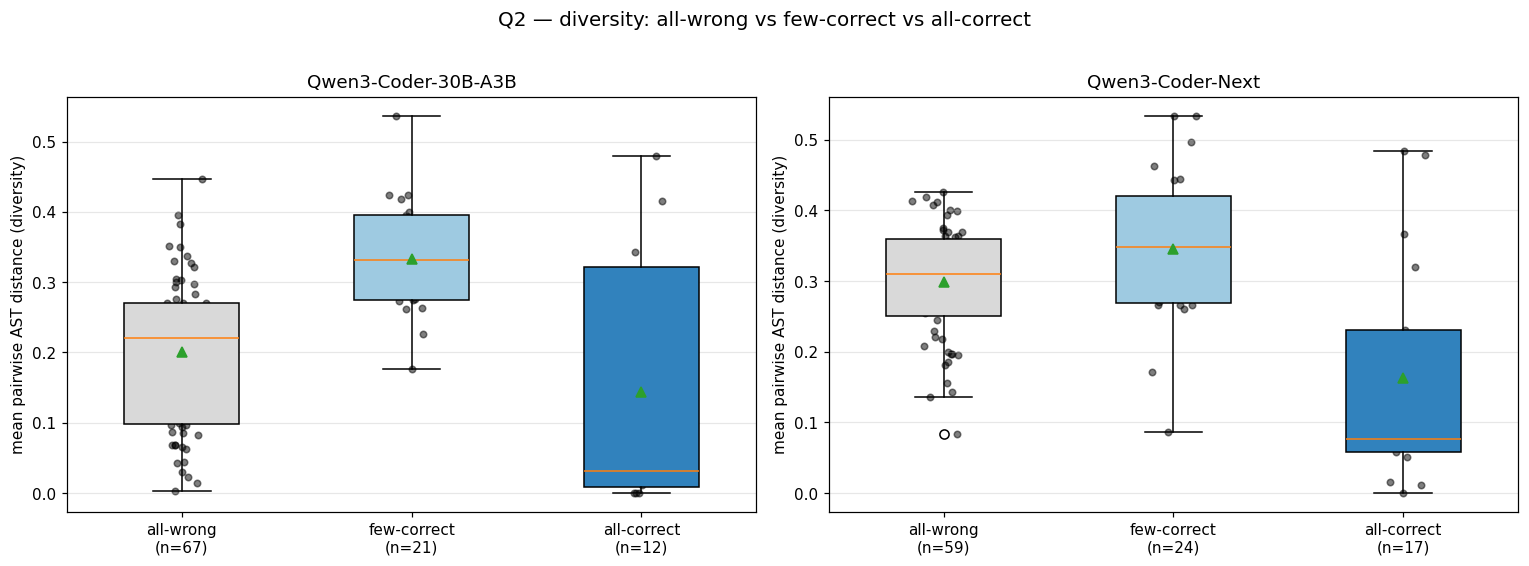

In [70]:
fig, axes = plt.subplots(1, len(data), figsize=(7 * len(data), 5), squeeze=False)
for ax, (label, (wrong, few, correct)) in zip(axes[0], groups.items()):
    parts  = [wrong.values, few.values, correct.values]
    labels = [
        f"all-wrong\n(n={len(wrong)})",
        f"few-correct\n(n={len(few)})",
        f"all-correct\n(n={len(correct)})",
    ]
    bp = ax.boxplot(parts, labels=labels, showmeans=True, patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], ["#d9d9d9", "#9ecae1", "#3182bd"]):
        patch.set_facecolor(c)
    for i, vals in enumerate(parts, start=1):
        ax.scatter(np.random.normal(i, 0.05, len(vals)), vals, alpha=0.5, s=18, color="k")
    ax.set_title(label)
    ax.set_ylabel("mean pairwise AST distance (diversity)")
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Q2 — diversity: all-wrong vs few-correct vs all-correct", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Q3 — Full gradient: diversity across exact correct-sample counts

Rather than a binary split, shows diversity for every exact correct count (0, 1, 2, 3, ≥4).
Each column is one bucket; the crimson bar is the median. Reveals whether the diversity jump is a sharp step at 0→1 or a gradual trend.

In [71]:
q3_rows = []
for label, df in data.items():
    d = df.dropna(subset=["diversity"])
    wrong = d.loc[d["correct"] == 0, "diversity"]
    few   = d.loc[(d["correct"] >= 1) & (d["correct"] <= FEW_MAX), "diversity"]
    row = dict(
        run=label,
        n_all_wrong=len(wrong),   mean_div_wrong=round(wrong.mean(), 3), median_div_wrong=round(wrong.median(), 3),
        n_few_correct=len(few),   mean_div_few=round(few.mean(), 3),     median_div_few=round(few.median(), 3),
    )
    if len(wrong) > 0 and len(few) > 0:
        u, p = stats.mannwhitneyu(few, wrong, alternative="greater")
        rb = 1 - 2 * u / (len(few) * len(wrong))
        row["p_few_gt_wrong"] = round(p, 4)
        row["rank_biserial"]  = round(-rb, 3)
    q3_rows.append(row)
print("Q3: diversity — all-wrong (correct=0) vs few-correct (1–FEW_MAX)")
pd.DataFrame(q3_rows)

Q3: diversity — all-wrong (correct=0) vs few-correct (1–FEW_MAX)


,run,n_all_wrong,mean_div_wrong,median_div_wrong,n_few_correct,mean_div_few,median_div_few,p_few_gt_wrong,rank_biserial
0,Qwen3-Coder-30B-A3B,67,0.201,0.220,21,0.334,0.332,0.0000,0.679
1,Qwen3-Coder-Next,59,0.298,0.309,24,0.346,0.348,0.0462,0.237


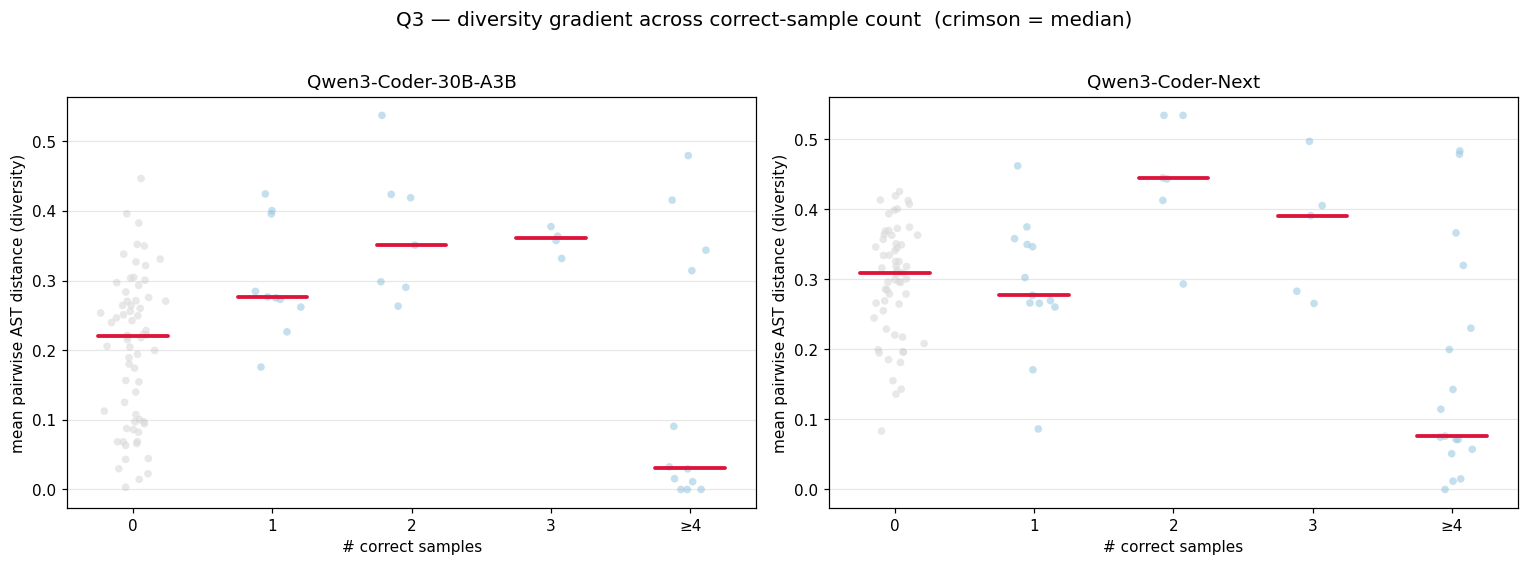

In [72]:
fig, axes = plt.subplots(1, len(data), figsize=(7 * len(data), 5), squeeze=False)
for ax, (label, df) in zip(axes[0], data.items()):
    d = df.dropna(subset=["diversity"]).copy()
    cap = FEW_MAX + 1
    d["correct_capped"] = d["correct"].clip(upper=cap)
    order = list(range(cap + 1))
    tick_labels = [str(k) if k < cap else f"\u2265{cap}" for k in order]

    for k in order:
        vals = d.loc[d["correct_capped"] == k, "diversity"].values
        if len(vals) == 0:
            continue
        color = "#d9d9d9" if k == 0 else "#9ecae1"
        ax.scatter(np.random.normal(k, 0.08, len(vals)), vals,
                   alpha=0.6, s=25, color=color, edgecolor="none")
        ax.plot([k - 0.25, k + 0.25], [np.median(vals), np.median(vals)],
                color="crimson", lw=2.5, solid_capstyle="round")

    ax.set_xticks(order)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel("# correct samples")
    ax.set_ylabel("mean pairwise AST distance (diversity)")
    ax.set_title(label)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Q3 — diversity gradient across correct-sample count  (crimson = median)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Notes
- `diversity` = mean pairwise **AST bigram-Jaccard distance** across a problem's samples (from `stage2_ast_struct_summary.csv`); higher = structurally more varied generations.
- Problems with fewer than 2 AST-parseable samples have undefined diversity and are dropped from the stats.
- Q1 correlates diversity against correctness over **all** problems; Q2 shows the three-group boxplot; Q3 shows the full per-count gradient.
- `all-correct` = `correct > FEW_MAX` (i.e. more than FEW_MAX=3 of the 10 samples are correct).
- Counts are small (≤100 problems, sub-buckets smaller still), so treat p-values as directional, not definitive.